@author Nikolay Zhabchikov

Предсказания основаны на поиске вхождения названия категории в описании. Описание и категория предварительно обрабатываются от лишних символов и затем применяется процесс приведения слова к изначальной форме (лемме) или нахождения основы слова (стемминг).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import re
import spacy
from nltk.stem.snowball import SnowballStemmer


tqdm.pandas()

In [2]:
df = pd.read_csv('data\monitorings_archive\Птица.csv')
cls_df = pd.read_csv('data\categories\Птица_разрубы.csv', sep=';')

df = df.rename(columns={'Категория': 'model_1', 'Новая Категория': 'model_2'})

In [3]:
df.head(1)

,Наименование,Описание,Зам./ Охл.,Страна,Упаковка,Наличие,Партия,Условия поставки,Цена,Компания,Вид деятельности,Телефон,Контактное лицо,E-mail,Дата,federal_okrug,Сорт/Категория,Сертификация,model_1,model_2
0,Индейка,Желудки подл.,зам,Россия,"короб 6,4 кг.",Склад,NaN,Возм. доставка,157.0,ООО РУСКОМ,Производитель,"(495) 640-09-10, (964) 647-23-76",Александр,sale2.moscow@sibkolbasy.ru,2015-01-14,NaN,NaN,NaN,гребешки,желудки


In [4]:
df.columns

Index(['Наименование', 'Описание', 'Зам./ Охл.', 'Страна', 'Упаковка',
       'Наличие', 'Партия', 'Условия поставки', 'Цена', 'Компания',
       'Вид деятельности', 'Телефон', 'Контактное лицо', 'E-mail', 'Дата',
       'federal_okrug', 'Сорт/Категория', 'Сертификация', 'model_1',
       'model_2'],
      dtype='object')

In [5]:
df = df.drop(['Зам./ Охл.', 'Страна', 'Упаковка',
       'Наличие', 'Партия', 'Условия поставки', 'Цена', 'Компания',
       'Вид деятельности', 'Телефон', 'Контактное лицо', 'E-mail', 'Дата',
       'federal_okrug', 'Сорт/Категория', 'Сертификация'], axis=1)

In [6]:
df.head(200)

,Наименование,Описание,model_1,model_2
0,Индейка,Желудки подл.,гребешки,желудки
1,Перепел,Тушка (20 шт),тушка,тушка
2,Перепел,Тушка 1 шт 175гр,тушка-суповая,тушка
3,Перепел,Тушка 130-150,тушка-несушка,тушка
4,Перепел,Тушка 220-240 гр,тушка-суповая,тушка
...,...,...,...,...
195,Кура,Фарш мон. гост,фарш,кость
196,Кура,Фарш премиум фас 1 кг.,жир (сырец),фарш
197,Кура,Фарш премиум фас 1 кг.,жир (сырец),фарш
198,Кура,Филе,филе,филе


In [7]:
cls_df['value'].unique()

array(['азу', 'ассорти', 'бедро', 'голень', 'головы', 'гребешки',
       'грудка', 'гузки', 'желудки', 'жир', 'жир (сырец)', 'каркас',
       'киль', 'Кишечник', 'кожа', 'костный остаток', 'кость', 'крыло',
       'лапы', 'микс', 'мякоть', 'мясо', 'мясо механической обвалки',
       'набор для бульона', 'набор для супа', 'набор для тушения',
       'набор для чахохбили', 'ноги', 'обрезь', 'окорочка', 'печень',
       'полутушка', 'рагу', 'седло', 'сердце', 'спинка', 'Субпродукты',
       'тримминг', 'тушка', 'тушка домашняя', 'тушка-корнишон',
       'тушка-несушка', 'тушка-суповая', 'фарш', 'филе', 'филе бедра',
       'филе грудки', 'филе окорочка', 'четвертина', 'шаурма', 'шашлык',
       'шея', 'шкура'], dtype=object)

# Лемматизация

In [8]:
nlp = spacy.load('ru_core_news_sm')

In [ ]:
def clear_description_lemma(text):
    '''
    Удаление лишних символов и лемматизация слов
    '''
    text = re.sub('[^а-яА-Я]+', ' ', text)
    text = text.lower().strip()
    text = ' '.join([word for word in text.split() if len(word) > 2])
    text = ' '.join([token.lemma_ for token in nlp(text)])
    return text

In [10]:
df['Описание лемматизация'] = df['Описание'].progress_apply(clear_description_lemma)

100%|██████████| 540013/540013 [34:19<00:00, 262.26it/s]


In [12]:
df[['Описание', 'Описание лемматизация']].head(10)

,Описание,Описание лемматизация
0,Желудки подл.,желудки подлый
1,Тушка (20 шт),тушка
2,Тушка 1 шт 175гр,тушка
3,Тушка 130-150,тушка
4,Тушка 220-240 гр,тушка
5,"Тушка 4шт./уп./0,140-0,160/ кг./шт",тушка
6,Тушка в/у премиум вес 200-240гр.,тушка премиум вес
7,Тушка в/у премиум вес 240-260гр.,тушка премиум вес
8,Тушка вакуумная упаковка вес 110-130 гр.,тушка вакуумный упаковка вес
9,Тушка вакуумная упаковка вес 130-150гр.,тушка вакуумный упаковка вес


In [13]:
cls_name = list(cls_df['value'].unique())
cls_name_lemma = [clear_description_lemma(i) for i in cls_name]

cls_name_lemma[26] = 'чахохбили'
cls_name_lemma[25] = 'тушение'
cls_name_lemma[23] = 'бульон'
cls_name_lemma[24] = 'суп'

lemma_to_class = {cls_name_lemma[i]:cls_name[i] for i in range(len(cls_name))}
cls_name_lemma = sorted(cls_name_lemma, key=len, reverse=True)

In [ ]:
def predict_lemma(text):
    '''
    Предсказание категории
    '''
    for i in cls_name_lemma:
        if i in text:
            return lemma_to_class.get(i, 'No preds')
    return 'No preds'

In [15]:
df['Категория лемматизация'] = df['Описание лемматизация'].progress_apply(predict_lemma)

100%|██████████| 540013/540013 [00:00<00:00, 598683.12it/s]


In [16]:
df[['Описание', 'Описание лемматизация', 'Категория лемматизация']].head(5)

,Описание,Описание лемматизация,Категория лемматизация
0,Желудки подл.,желудки подлый,желудки
1,Тушка (20 шт),тушка,тушка
2,Тушка 1 шт 175гр,тушка,тушка
3,Тушка 130-150,тушка,тушка
4,Тушка 220-240 гр,тушка,тушка


In [17]:
df[['model_1', 'model_2', 'Категория лемматизация']].describe()

,model_1,model_2,Категория лемматизация
count,540013,540013,540013
unique,53,54,52
top,филе грудки,филе,тушка
freq,63946,77729,68175


In [18]:
model_1_to_2 = len(df[df['model_1'] == df['model_2']])
model_1_to_lemma = len(df[df['model_1'] == df['Категория лемматизация']])
model_2_to_lemma = len(df[df['model_2'] == df['Категория лемматизация']])

print(f'Всего объектов: {len(df)}')
print(f'совпадений между 1 и 2 моделью: {model_1_to_2} / {str(round(model_1_to_2/len(df), 4) * 100)}%')
print(f'совпадений между моделью 1 и алгоритмом лемматизации: {model_1_to_lemma} / {str(round(model_1_to_lemma/len(df), 4) * 100)}%')
print(f'совпадений между моделью 2 и алгоритмом лемматизации: {model_2_to_lemma} / {str(round(model_2_to_lemma/len(df), 4) * 100)}%')

Всего объектов: 540013
совпадений между 1 и 2 моделью: 291504 / 53.98%
совпадений между моделью 1 и алгоритмом лемматизации: 365522 / 67.69%
совпадений между моделью 2 и алгоритмом лемматизации: 445663 / 82.53%


In [19]:
no_preds = len(df[df['Категория лемматизация'] == 'No preds'])
f'количество пропущенных предсказаний у алгоритма лемматизации: {no_preds} / {str(round(no_preds/len(df), 4) * 100)}%'

'количество пропущенных предсказаний у алгоритма лемматизации: 7384 / 1.37%'

# Стемминг

In [20]:
stemmer = SnowballStemmer("russian") 

In [ ]:
def clear_description_stemming(text):
    '''
    Удаление лишних символов и стемминг слов
    '''
    text = re.sub('[^а-яА-Я]+', ' ', text)
    text = text.lower().strip()
    text = ' '.join([stemmer.stem(word) for word in text.split() if len(word) > 2])
    return text

In [22]:
df['Описание стемминг'] = df['Описание'].progress_apply(clear_description_stemming)

100%|██████████| 540013/540013 [00:46<00:00, 11529.53it/s]


In [23]:
df[['Описание', 'Описание стемминг']].head(5)

,Описание,Описание стемминг
0,Желудки подл.,желудк подл
1,Тушка (20 шт),тушк
2,Тушка 1 шт 175гр,тушк
3,Тушка 130-150,тушк
4,Тушка 220-240 гр,тушк


In [24]:
cls_name_stemming = [clear_description_stemming(i) for i in cls_name]

cls_name_stemming[26] = 'чахохб'
cls_name_stemming[25] = 'тушен'
cls_name_stemming[23] = 'бульон'
cls_name_stemming[24] = 'суп'

stemming_to_class = {cls_name_stemming[i]:cls_name[i] for i in range(len(cls_name))}
cls_name_stemming = sorted(cls_name_stemming, key=len, reverse=True)

In [ ]:
def predict_stemming(text):
    '''
    Предсказание категории
    '''
    for i in cls_name_stemming:
        if i in text:
            return stemming_to_class.get(i, 'No preds')
    return 'No preds'

In [26]:
df['Категория стемминг'] = df['Описание стемминг'].progress_apply(predict_stemming)

100%|██████████| 540013/540013 [00:00<00:00, 618551.39it/s]


In [27]:
df[['model_1', 'model_2', 'Категория стемминг']].describe()

,model_1,model_2,Категория стемминг
count,540013,540013,540013
unique,53,54,52
top,филе грудки,филе,тушка
freq,63946,77729,68147


In [28]:
model_1_to_2 = len(df[df['model_1'] == df['model_2']])
model_1_to_stemming = len(df[df['model_1'] == df['Категория стемминг']])
model_2_to_stemming = len(df[df['model_2'] == df['Категория стемминг']])

print(f'Всего объектов: {len(df)}')
print(f'совпадений между 1 и 2 моделью: {model_1_to_2} / {str(round(model_1_to_2/len(df), 4) * 100)}%')
print(f'совпадений между моделью 1 и стемминг алгоритмом: {model_1_to_stemming} / {str(round(model_1_to_stemming/len(df), 4) * 100)}%')
print(f'совпадений между моделью 2 и стемминг алгоритмом: {model_2_to_stemming} / {str(round(model_2_to_stemming/len(df), 4) * 100)}%')

Всего объектов: 540013
совпадений между 1 и 2 моделью: 291504 / 53.98%
совпадений между моделью 1 и стемминг алгоритмом: 371011 / 68.7%
совпадений между моделью 2 и стемминг алгоритмом: 438582 / 81.22%


In [29]:
no_preds = len(df[df['Категория стемминг'] == 'No preds'])
f'количество пропущенных предсказаний у стемминг алгоритма: {no_preds} / {str(round(no_preds/len(df), 4) * 100)}%'

'количество пропущенных предсказаний у стемминг алгоритма: 6155 / 1.1400000000000001%'

In [31]:
lemma_to_stemming = len(df[(df['Категория лемматизация'] == df['Категория стемминг']) & (df['Категория лемматизация'] != 'No preds')])
print(f'совпадений между лемматизацией и стемминг алгоритмами: {lemma_to_stemming} / {str(round(lemma_to_stemming/len(df), 4) * 100)}%')

совпадений между лемматизацией и стемминг алгоритмами: 521817 / 96.63000000000001%


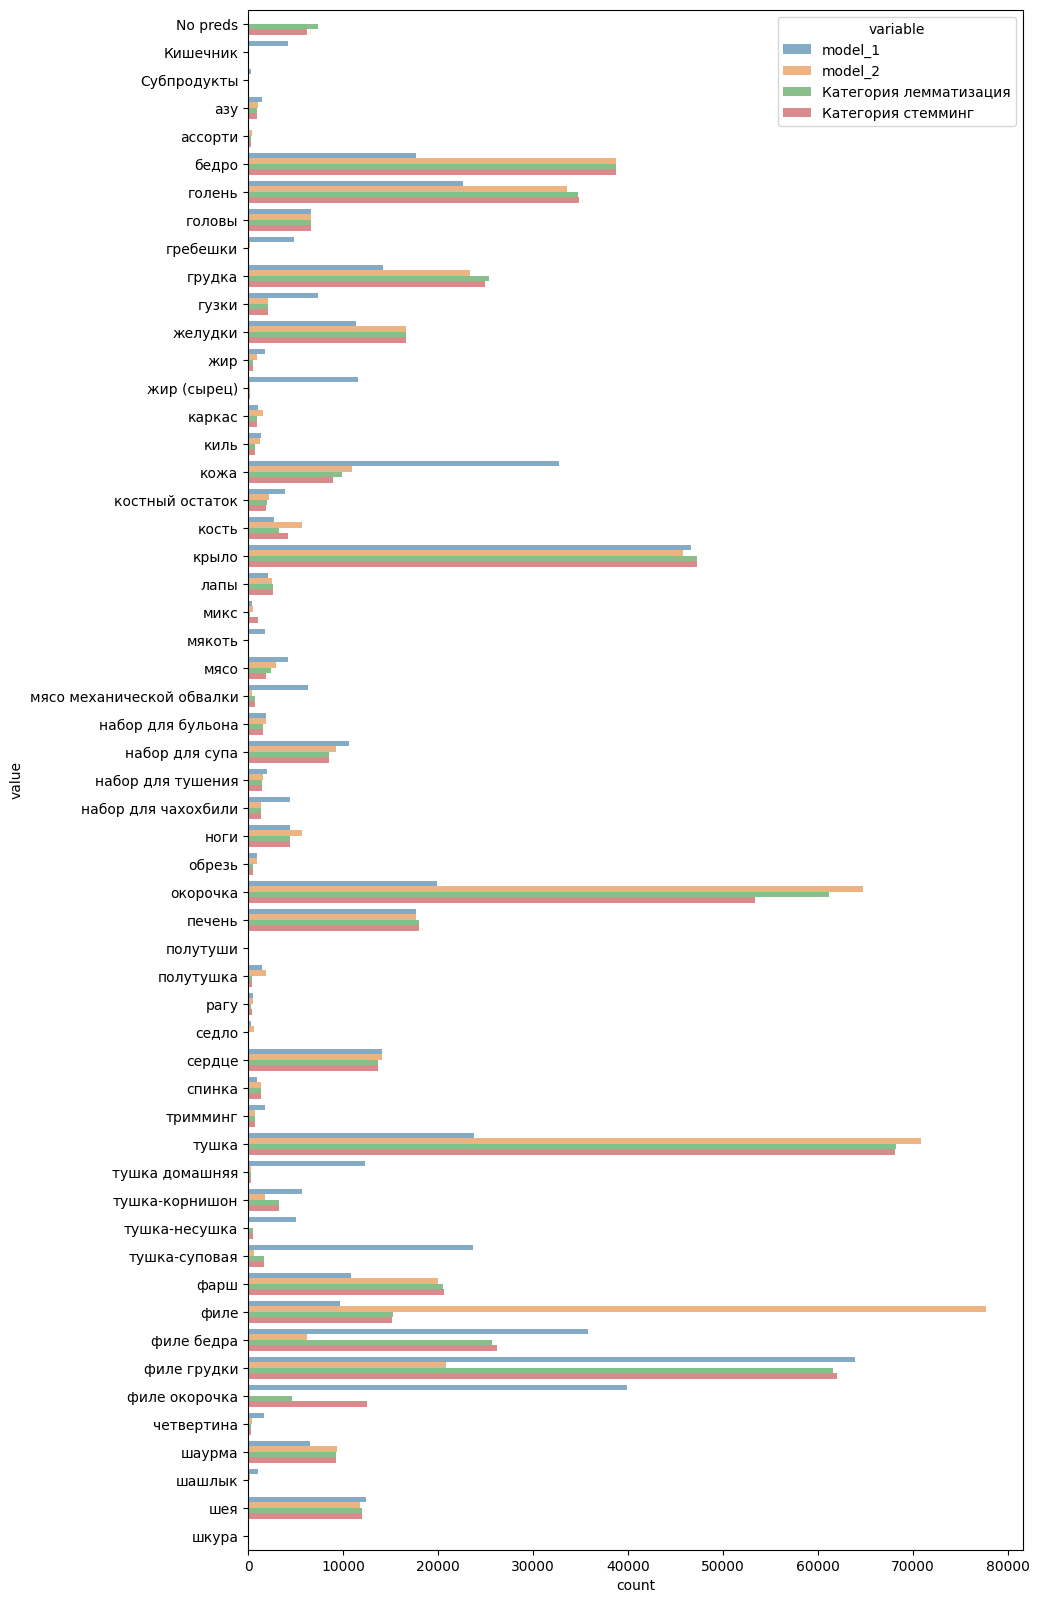

In [34]:
data = df.melt(value_vars=['model_1', 'model_2', 'Категория лемматизация', 'Категория стемминг'])
names = list(data['value'].unique())
names.sort()
plt.figure(figsize=(10, 20))
sns.countplot(y='value', data=data, hue='variable', alpha=0.6, order=names)
plt.show()

Достаточно простые алгоритмы основанные на вхождении названия категории в описании. Из явных проблем никак не учитывается порядок слов, различные слова отрицания "без, не", не предсказывает  категорию где в описании содержится слова из разных категорий (предсказывается наиболее длинное название категории), необходимость анализа названий категорий для каждого датасета